In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

# Read and clean data

In [2]:
data_folder = 'C:/Users/Graham West/Python Notebooks/Meharry Teaching/Datasets/'

df = pd.read_csv(data_folder + 'Real Estate/Real Estate Data.csv', index_col=0, header=0)
df = df.reset_index(drop=True)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1404 entries, 0 to 1403
Data columns (total 68 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Type                      1404 non-null   object 
 1   Zoning Class              1404 non-null   object 
 2   Lot Frontage              1151 non-null   float64
 3   Lot Area                  1404 non-null   int64  
 4   Alley                     84 non-null     object 
 5   Lot Shape                 1404 non-null   object 
 6   Land Contour              1404 non-null   object 
 7   Lot Config                1404 non-null   object 
 8   Land Slope                1404 non-null   object 
 9   Nbhd                      1404 non-null   object 
 10  Location Condition        1404 non-null   object 
 11  Bldg Type                 1404 non-null   object 
 12  House Style               1404 non-null   object 
 13  OvQual                    1404 non-null   int64  
 14  Overall 

,Type,Zoning Class,Lot Frontage,Lot Area,Alley,Lot Shape,Land Contour,Lot Config,Land Slope,Nbhd,Location Condition,Bldg Type,House Style,OvQual,Overall Cond,Built,Year Remod Add,Roof Style,Roof Material,Exterior Primary,Masonry/Veneer,Masonry/Veneer Area,Exterior Qual,Exterior Cond,Foundation,Basement Height,Basement Cond,Basement Exposure,Basement Finish,Basement Finished Area,Basement Unfinished Area,Basement Area,Heating Qual,CentralAir,Electrical,1st Floor Area,2nd Floor Area,Living Area Above Grade,Basement Full Baths,Basement Half baths,Full Baths Above Grade,Half Baths Above Grade,Bedrooms Above Grade,Kitchens Above Grade,Kitchen Qual,Total Rooms Above Grade,Functionality,Fireplaces,Fireplce Qual,Garage Type,Garage Yr Built,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck Area,Open Porch Area,Enclosed Porch Area,3 Season Porch Area,Screen Porch Area,Pool Area,Pool Qual,Fence,Sale Type,Sale Condition,Sale Price
0,2-STORY 1946 & NEWER,Resid Low Density,65.0,8450,NaN,Regular,Level,Inside lot,Gentle,College Creek,Normal,1-family Detached,2 story,7,5,2003,2003,Gable,Composite Shingle,Vinyl Siding,Brick Face,196.0,Good,Average,Poured Contrete,"Good (90-99"")",Average,No Exposure,Good Living Quarters,706,150,856,Excellent,Y,Standard Circuit Breakers & Romex,856,854,1710,1,0,2,1,3,1,Good,8,Typical Functionality,0,No Fireplace,Attached to home,2003.0,Rough Finished,2,548,Average,Average,Paved,0,61,0,0,0,0,No Pool,No Fence,Warranty Deed - Conventional,Normal Sale,208500
1,1-STORY 1946 & NEWER,Resid Low Density,80.0,9600,NaN,Regular,Level,Frontage on 2 sides,Gentle,Veenker,Adjacent Feeder St,1-family Detached,1 story,6,8,1976,1976,Gable,Composite Shingle,Metal Siding,NaN,0.0,Average,Average,Cinder Block,"Good (90-99"")",Average,Good Exposure,Avg Living Quarters,978,284,1262,Excellent,Y,Standard Circuit Breakers & Romex,1262,0,1262,0,1,2,0,3,1,Average,6,Typical Functionality,1,Average,Attached to home,1976.0,Rough Finished,2,460,Average,Average,Paved,298,0,0,0,0,0,No Pool,No Fence,Warranty Deed - Conventional,Normal Sale,181500
2,2-STORY 1946 & NEWER,Resid Low Density,68.0,11250,NaN,Slightly irregular,Level,Inside lot,Gentle,College Creek,Normal,1-family Detached,2 story,7,5,2001,2002,Gable,Composite Shingle,Vinyl Siding,Brick Face,162.0,Good,Average,Poured Contrete,"Good (90-99"")",Average,Min Exposure,Good Living Quarters,486,434,920,Excellent,Y,Standard Circuit Breakers & Romex,920,866,1786,1,0,2,1,3,1,Good,6,Typical Functionality,1,Average,Attached to home,2001.0,Rough Finished,2,608,Average,Average,Paved,0,42,0,0,0,0,No Pool,No Fence,Warranty Deed - Conventional,Normal Sale,223500
3,2-STORY 1945 & OLDER,Resid Low Density,60.0,9550,NaN,Slightly irregular,Level,Corner lot,Gentle,Crawford,Normal,1-family Detached,2 story,7,5,1915,1970,Gable,Composite Shingle,Wood Siding,NaN,0.0,Average,Average,Brick & Tile,"Typical (80-89"")",Good,No Exposure,Avg Living Quarters,216,540,756,Good,Y,Standard Circuit Breakers & Romex,961,756,1717,1,0,1,0,3,1,Good,7,Typical Functionality,1,Good,Detached from home,1998.0,Unfinished,3,642,Average,Average,Paved,0,35,272,0,0,0,No Pool,No Fence,Warranty Deed - Conventional,"Abnormal Sale - trade, foreclosure, short sale",140000
4,2-STORY 1946 & NEWER,Resid Low Density,84.0,14260,NaN,Slightly irregular,Level,Frontage on 2 sides,Gentle,Northridge,Normal,1-family Detached,2 story,8,5,2000,2000,Gable,Composite Shingle,Vinyl Siding,Brick Face,350.0,Good,Average,Poured Contrete,"Good (90-99"")",Average,Avg Exposure,Good Living Quarters,655,490,1145,Excellent,Y,Standard Circuit Breakers & Romex,1145,1053,2198,1,0,2,1,4,1,Good,9,Typical Functionality,1,Average,Attached to home,2000.0,Rough Finished,3,836,Average,Average,Paved,192,84,0,0,0,0,No Pool,No Fence,Warranty Deed - Conventional,Normal Sale,250000


### Rename columns

In [3]:
df = df.rename(columns = {'OvQual':'Overall Qual',
                          'Built':'Year',
                          'Garage Yr Built':'Year Garage'})

### Drop Alley column

In [4]:
df = df.drop(columns=['Alley'])

### Fill nans

In [5]:
df.isna().sum(axis=0).sort_values(ascending=False)

Masonry/Veneer              824
Lot Frontage                253
Year Garage                  63
Masonry/Veneer Area           8
Total Rooms Above Grade       0
Garage Type                   0
Fireplce Qual                 0
Fireplaces                    0
Functionality                 0
Type                          0
Garage Finish                 0
Kitchens Above Grade          0
Bedrooms Above Grade          0
Half Baths Above Grade        0
Full Baths Above Grade        0
Basement Half baths           0
Basement Full Baths           0
Kitchen Qual                  0
Garage Cars                   0
2nd Floor Area                0
Garage Area                   0
Garage Qual                   0
Garage Cond                   0
Paved Drive                   0
Wood Deck Area                0
Open Porch Area               0
Enclosed Porch Area           0
3 Season Porch Area           0
Screen Porch Area             0
Pool Area                     0
Pool Qual                     0
Fence   

In [6]:
gb1 = df.groupby(["Nbhd"])['Lot Frontage'].median().sort_values()

def fill_1(r):
    n = r.Nbhd
    
    x = r['Lot Frontage']
    
    if pd.isna(x):
        return gb1[n]
    else:
        return x
    # end
# end

df['Lot Frontage'] = df.apply(fill_1, axis=1)

In [7]:
gb2 = df.groupby(["Nbhd"])['Year Garage'].median().sort_values()

def fill_2(r):
    n = r.Nbhd
    
    x = r['Year Garage']
    
    if pd.isna(x):
        return gb2[n]
    else:
        return x
    # end
# end

df['Year Garage'] = df.apply(fill_2, axis=1)

In [8]:
gb3 = df.groupby(["Nbhd"])['Masonry/Veneer Area'].median().sort_values()

def fill_3(r):
    n = r.Nbhd
    
    x = r['Masonry/Veneer Area']
    
    if pd.isna(x):
        return gb2[n]
    else:
        return x
    # end
# end

df['Masonry/Veneer Area'] = df.apply(fill_3, axis=1)

In [9]:
df.isna().sum(axis=0).sort_values(ascending=False)

Masonry/Veneer              824
Type                          0
Kitchen Qual                  0
Garage Type                   0
Fireplce Qual                 0
Fireplaces                    0
Functionality                 0
Total Rooms Above Grade       0
Kitchens Above Grade          0
1st Floor Area                0
Bedrooms Above Grade          0
Half Baths Above Grade        0
Full Baths Above Grade        0
Basement Half baths           0
Basement Full Baths           0
Living Area Above Grade       0
Year Garage                   0
Garage Finish                 0
Garage Cars                   0
Garage Area                   0
Garage Qual                   0
Garage Cond                   0
Paved Drive                   0
Wood Deck Area                0
Open Porch Area               0
Enclosed Porch Area           0
3 Season Porch Area           0
Screen Porch Area             0
Pool Area                     0
Pool Qual                     0
Fence                         0
Sale Typ

### Drop Masonry/Veneer column

In [10]:
df = df.drop(columns=['Masonry/Veneer'])

# Feature engineering

### Floors

In [11]:
def get_floors(x):
    if x > 0:
        return 2
    else:
        return 1
    # end
# end

df['Floors'] = df['2nd Floor Area'].apply(get_floors)

### Areas

In [12]:
df['Indoor Area'] = df[
    [
        '1st Floor Area', '2nd Floor Area', 'Basement Area'
    ]
].sum(axis=1)

df['Outdoor Area'] = df[
    [
        '3 Season Porch Area', 'Enclosed Porch Area', 'Garage Area',
        'Open Porch Area', 'Pool Area', 'Screen Porch Area', 'Wood Deck Area'
    ]
].sum(axis=1)

df['Basement Finished Area Fraction'] = df['Basement Finished Area'] / df[['Basement Finished Area', 'Basement Unfinished Area']].sum(axis=1)
df['Basement Finished Area Fraction'] = df['Basement Finished Area Fraction'].fillna(0)

In [13]:
df = df.drop(
    columns=[
       '1st Floor Area', '2nd Floor Area', '3 Season Porch Area',
       'Basement Area', 'Basement Finished Area', 'Basement Unfinished Area',
       'Enclosed Porch Area', 'Garage Area', 'Living Area Above Grade',
       'Open Porch Area', 'Pool Area', 'Screen Porch Area', 'Wood Deck Area'
    ]
)

### Label encode qualities

In [14]:
from sklearn.preprocessing import OrdinalEncoder

# Define known categories
quality_order = ["Poor", "Fair", "Average", "Good", "Excellent"]

# Identify categorical columns that contain 'Average'
cols = df.columns[df.isin(['Average']).any(axis=0)]

# Replace unknown values with "Poor"
df[cols] = df[cols].applymap(lambda x: x if x in quality_order else "Poor")

# Initialize and fit OrdinalEncoder on a single-column DataFrame
encoder = OrdinalEncoder(
    categories=[quality_order]
)

encoder.fit(
    np.array(quality_order)[:,np.newaxis]
)

# Transform each column separately in a loop
for c in cols:
    df[c] = encoder.transform(df[[c]]).astype(int)[:,0]
# end

In [15]:
df['Basement Height'] = df['Basement Height'].apply(
    lambda x: x.split(" ")[0]
)

df['Basement Height'] = df['Basement Height'].apply(
    lambda x: x if x != "Typical" else "Average"
)

df['Basement Height'] = df['Basement Height'].apply(
    lambda x: x if x in quality_order else "Poor"
)

df['Basement Height'] = encoder.transform(df[['Basement Height']]).astype(int)[:,0]

In [16]:
df['Pool Qual'] = df['Pool Qual'].apply(
    lambda x: x if x in quality_order else "Poor"
)

df['Pool Qual'] = encoder.transform(df[['Pool Qual']]).astype(int)[:,0]

### Central Air

In [17]:
df['CentralAir'] = df['CentralAir'].replace(
    {
        'Y':1,
        'N':0
    }
)

df = df.rename(
    columns={
        'CentralAir':'Central Air'
    }
)

# Preprocess data

In [18]:
df.sample(5)

,Type,Zoning Class,Lot Frontage,Lot Area,Lot Shape,Land Contour,Lot Config,Land Slope,Nbhd,Location Condition,Bldg Type,House Style,Overall Qual,Overall Cond,Year,Year Remod Add,Roof Style,Roof Material,Exterior Primary,Masonry/Veneer Area,Exterior Qual,Exterior Cond,Foundation,Basement Height,Basement Cond,Basement Exposure,Basement Finish,Heating Qual,Central Air,Electrical,Basement Full Baths,Basement Half baths,Full Baths Above Grade,Half Baths Above Grade,Bedrooms Above Grade,Kitchens Above Grade,Kitchen Qual,Total Rooms Above Grade,Functionality,Fireplaces,Fireplce Qual,Garage Type,Year Garage,Garage Finish,Garage Cars,Garage Qual,Garage Cond,Paved Drive,Pool Qual,Fence,Sale Type,Sale Condition,Sale Price,Floors,Indoor Area,Outdoor Area,Basement Finished Area Fraction
1398,1-STORY 1946 & NEWER,Floating Village Resid,62.0,7500,Regular,Level,Inside lot,Gentle,Somerset,Normal,1-family Detached,1 story,7,5,2004,2005,Gable,Composite Shingle,Vinyl Siding,0.0,3,2,Poured Contrete,3,2,No Exposure,Good Living Quarters,4,1,Standard Circuit Breakers & Romex,1,0,2,0,2,1,3,6,Typical Functionality,0,0,Attached to home,2004.0,Rough Finished,2,2,2,Paved,0,No Fence,Warranty Deed - Conventional,Normal Sale,185000,1,2442,513,0.335790
804,2-STORY PUD,Resid Med Density,21.0,1680,Regular,Level,Inside lot,Gentle,Briardale,Normal,Townhouse,2 story,6,5,1973,1973,Gable,Composite Shingle,Hard Board,158.0,2,2,Cinder Block,2,2,No Exposure,Below Avg Living Quarters,2,1,Standard Circuit Breakers & Romex,1,0,1,1,2,1,2,5,Typical Functionality,0,0,Detached from home,1973.0,Unfinished,1,2,2,Paved,0,No Fence,Warranty Deed - Conventional,Normal Sale,100000,2,1470,264,0.683230
710,1-STORY 1946 & NEWER,Resid Low Density,65.0,6768,Slightly irregular,Level,Inside lot,Gentle,Sawyer,Adjacent Feeder St,1-family Detached,1 story,6,8,1961,1996,Hip,Composite Shingle,Hard Board,0.0,2,3,Cinder Block,2,2,Min Exposure,Good Living Quarters,3,1,Standard Circuit Breakers & Romex,1,1,1,0,3,1,3,5,Typical Functionality,0,0,Detached from home,1962.0,Unfinished,1,2,2,Paved,0,Good Privacy,Warranty Deed - Conventional,Normal Sale,142000,1,1824,456,0.912281
1171,DUPLEX,Resid Med Density,68.0,8930,Regular,Level,Inside lot,Gentle,Sawyer,Adjacent Railroad,Duplex,1.5 story: 2nd level fin,6,5,1978,1978,Gable,Composite Shingle,Vinyl Siding,0.0,2,2,Slab,0,0,No Basement,No Basement,2,1,Standard Circuit Breakers & Romex,0,0,2,0,4,2,2,8,Typical Functionality,0,0,Attached to home,1978.0,Unfinished,2,2,2,Paved,0,No Fence,Warranty Deed - Conventional,Normal Sale,112000,2,1902,539,0.000000
1191,2-STORY PUD,Resid Low Density,36.0,2628,Regular,Level,Inside lot,Gentle,Northridge Heights,Normal,Townhouse,2 story,7,5,2003,2003,Gable,Composite Shingle,Vinyl Siding,106.0,3,2,Poured Contrete,3,2,No Exposure,Unfinshed,4,1,Standard Circuit Breakers & Romex,0,0,2,1,2,1,3,6,Typical Functionality,0,0,Built-In (Garage with Room),2003.0,Rough Finished,2,2,2,Paved,0,No Fence,Warranty Deed - Conventional,Normal Sale,175500,2,2390,501,0.000000


In [19]:
label = 'Overall Qual'
vc = df[label].value_counts().sort_index()
vc

Overall Qual
1       2
2       2
3      15
4     102
5     380
6     359
7     316
8     167
9      43
10     18
Name: count, dtype: int64

In [20]:
min_samp = 20

df = df[ df['Overall Qual'].isin(vc[vc>=min_samp].index) ].reset_index(drop=True)

X_raw = df.drop(columns=[label])
y = df[label].copy()

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(y)
y = le.transform(y)

y = pd.Series(y)
y.value_counts().sort_index()

0    102
1    380
2    359
3    316
4    167
5     43
Name: count, dtype: int64

### Split numeric and categorical columns for separate processing

In [21]:
X_num = X_raw.select_dtypes(exclude=object)
X_cat = X_raw.select_dtypes(include=object)

### Process numerical data in several ways

In [22]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()

X_num_ss = pd.DataFrame()
for c in X_num.columns:
    X_num_ss[c] = std_scaler.fit_transform(X_num[[c]])[:,0]
# end

### Get categorical dummies

In [23]:
X_dum = pd.DataFrame()
for c in X_cat.columns:
    dummy = pd.get_dummies(X_cat[c], prefix=c, dtype=int)
    dummy_sum = dummy.sum(axis=0)
    col_to_drop = dummy_sum.idxmax()
    dummy = dummy.drop(columns=[col_to_drop])
    X_dum = pd.concat([X_dum, dummy], axis=1)
# end
X_dum.head()

,Type_1 STORY PUD,Type_1-1/2 STORY ALL AGES,Type_1-STORY 1945 & OLDER,Type_1-STORY PUD,Type_2 FAMILY CONVERSION,Type_2-1/2 STORY ALL AGES,Type_2-STORY 1945 & OLDER,Type_2-STORY 1946 & NEWER,Type_2-STORY PUD,Type_DUPLEX,Type_SPLIT FOYER,Type_SPLIT OR MULTI-LEVEL,Zoning Class_Commercial,Zoning Class_Floating Village Resid,Zoning Class_Resid High Density,Zoning Class_Resid Med Density,Lot Shape_Irregular,Lot Shape_Slightly irregular,Land Contour_Banked,Land Contour_Depression,Land Contour_Hillside,Lot Config_Corner lot,Lot Config_Cul-de-sac,Lot Config_Frontage on 2 sides,Lot Config_Frontage on 3 sides,Land Slope_Moderate,Land Slope_Severe,Nbhd_Bloomington Heights,Nbhd_Bloomington Hts,Nbhd_Bluestem,Nbhd_Briardale,Nbhd_Brookside,Nbhd_Clear Creek,Nbhd_College Creek,Nbhd_Crawford,Nbhd_Edwards,Nbhd_Gilbert,Nbhd_Iowa DOT and Rail Road,Nbhd_Meadow Village,Nbhd_Mitchell,Nbhd_Northpark Villa,Nbhd_Northridge,Nbhd_Northridge Heights,Nbhd_Northwest Ames,Nbhd_Old Town,Nbhd_Sawyer,Nbhd_Sawyer West,Nbhd_Somerset,Nbhd_South & West of Iowa State,Nbhd_Stone Brook,...,Exterior Primary_Stucco,Exterior Primary_Wood Shingles,Exterior Primary_Wood Siding,Foundation_Brick & Tile,Foundation_Cinder Block,Foundation_Slab,Foundation_Stone,Foundation_Wood,Basement Exposure_Avg Exposure,Basement Exposure_Good Exposure,Basement Exposure_Min Exposure,Basement Exposure_No Basement,Basement Finish_Avg Living Quarters,Basement Finish_Avg Rec Room,Basement Finish_Below Avg Living Quarters,Basement Finish_Good Living Quarters,Basement Finish_Low Quality,Basement Finish_No Basement,Electrical_60 AMP Fuse Box and mostly Romex wiring (Fair),Electrical_Fuse Box over 60 AMP and all Romex wiring (Average),Functionality_Major Deductions 1,Functionality_Minor Deductions 1,Functionality_Minor Deductions 2,Functionality_Moderate Deductions,Garage Type_Basement Garage,Garage Type_Built-In (Garage with Room),Garage Type_Car Port,Garage Type_Detached from home,Garage Type_More than one type of garage,Garage Type_No Garage,Garage Finish_Finished,Garage Finish_No Garage,Garage Finish_Rough Finished,Paved Drive_Dirt/Gravel,Paved Drive_Partial Pavement,Fence_Good Privacy,Fence_Good Wood,Fence_Minimum Privacy,Fence_Minimum Wood/Wire,Sale Type_Contract 15% Down payment regular terms,Sale Type_Contract Low Down,Sale Type_Contract Low Down payment and low interest,Sale Type_Contract Low Interest,Sale Type_Court Officer Deed/Estate,Sale Type_Home just constructed and sold,Sale Type_Warranty Deed - Cash,"Sale Condition_Abnormal Sale - trade, foreclosure, short sale","Sale Condition_Allocation - two linked properties with separate deeds, typically condo with a garage unit",Sale Condition_Home was not completed when last assessed (associated with New Homes),Sale Condition_Sale between family members
0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


# Modeling

In [24]:
X = pd.concat([X_num_ss, X_dum], axis=1)

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y
)

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

models = [
    LogisticRegression(),
    KNeighborsClassifier(n_neighbors=5,   weights='uniform'),
    KNeighborsClassifier(n_neighbors=10,  weights='uniform'),
    KNeighborsClassifier(n_neighbors=50,  weights='uniform'),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=3),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=10),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=30),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=10),
]

LogisticRegression()
              precision    recall  f1-score   support

           0       0.44      0.35      0.39        20
           1       0.59      0.64      0.62        76
           2       0.58      0.57      0.57        72
           3       0.58      0.60      0.59        63
           4       0.55      0.53      0.54        34
           5       0.67      0.44      0.53         9

    accuracy                           0.57       274
   macro avg       0.57      0.52      0.54       274
weighted avg       0.57      0.57      0.57       274



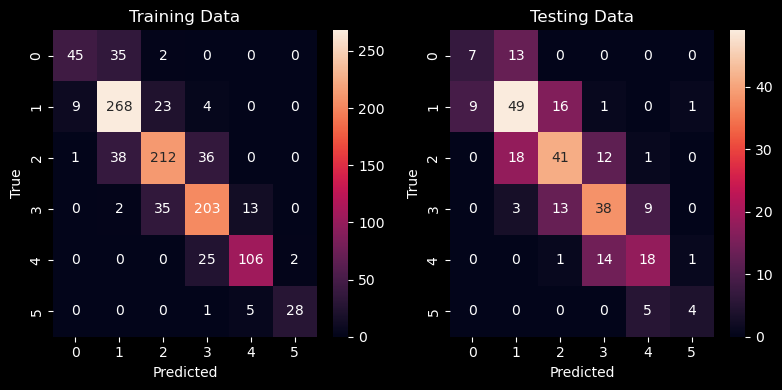

KNeighborsClassifier()
              precision    recall  f1-score   support

           0       0.23      0.15      0.18        20
           1       0.52      0.62      0.56        76
           2       0.51      0.53      0.52        72
           3       0.57      0.62      0.60        63
           4       0.61      0.41      0.49        34
           5       0.80      0.44      0.57         9

    accuracy                           0.53       274
   macro avg       0.54      0.46      0.49       274
weighted avg       0.53      0.53      0.52       274



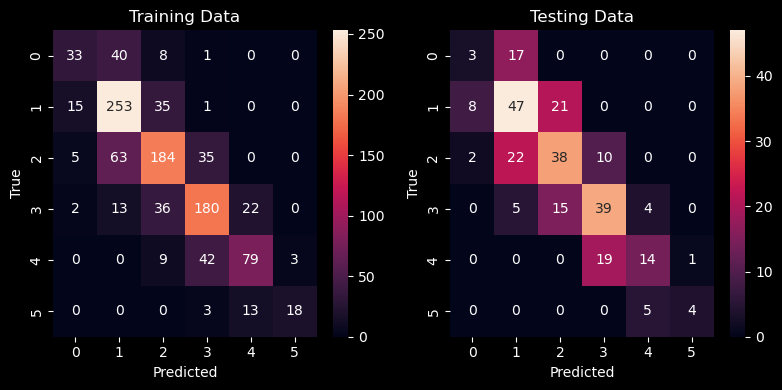

KNeighborsClassifier(n_neighbors=10)
              precision    recall  f1-score   support

           0       0.45      0.25      0.32        20
           1       0.56      0.66      0.61        76
           2       0.52      0.54      0.53        72
           3       0.56      0.63      0.59        63
           4       0.65      0.44      0.53        34
           5       1.00      0.44      0.62         9

    accuracy                           0.56       274
   macro avg       0.62      0.50      0.53       274
weighted avg       0.57      0.56      0.55       274



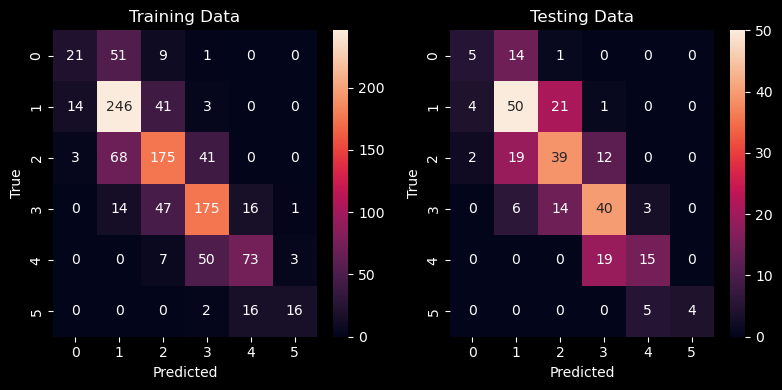

KNeighborsClassifier(n_neighbors=50)
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        20
           1       0.53      0.84      0.65        76
           2       0.49      0.33      0.40        72
           3       0.53      0.62      0.57        63
           4       0.60      0.53      0.56        34
           5       1.00      0.11      0.20         9

    accuracy                           0.53       274
   macro avg       0.53      0.41      0.40       274
weighted avg       0.51      0.53      0.49       274



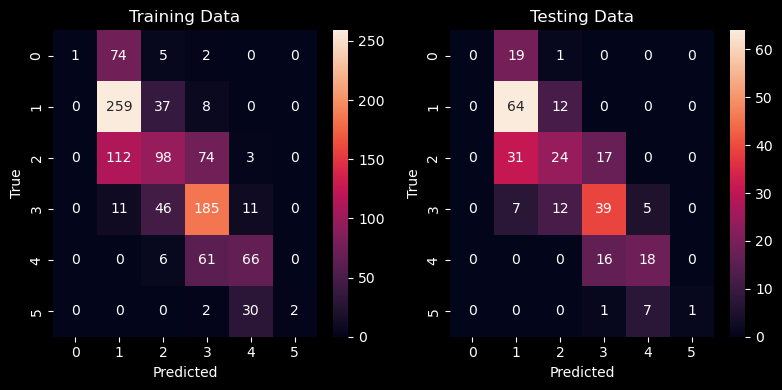

RandomForestClassifier(max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        20
           1       0.51      0.95      0.66        76
           2       0.54      0.18      0.27        72
           3       0.44      0.75      0.55        63
           4       0.00      0.00      0.00        34
           5       0.00      0.00      0.00         9

    accuracy                           0.48       274
   macro avg       0.25      0.31      0.25       274
weighted avg       0.38      0.48      0.38       274



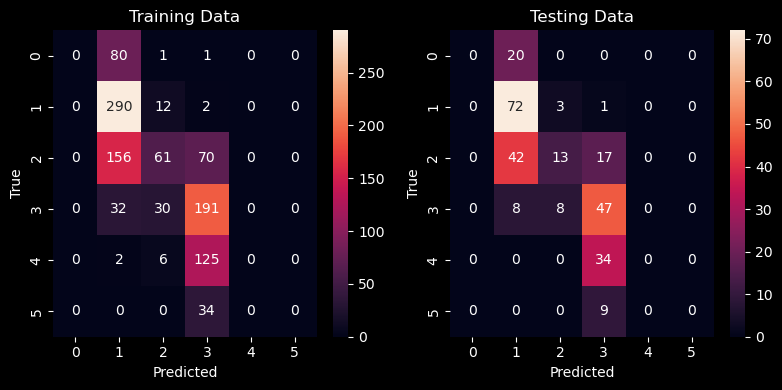

RandomForestClassifier(max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        20
           1       0.53      0.87      0.66        76
           2       0.52      0.35      0.42        72
           3       0.61      0.68      0.64        63
           4       0.61      0.56      0.58        34
           5       0.00      0.00      0.00         9

    accuracy                           0.56       274
   macro avg       0.38      0.41      0.38       274
weighted avg       0.50      0.56      0.51       274



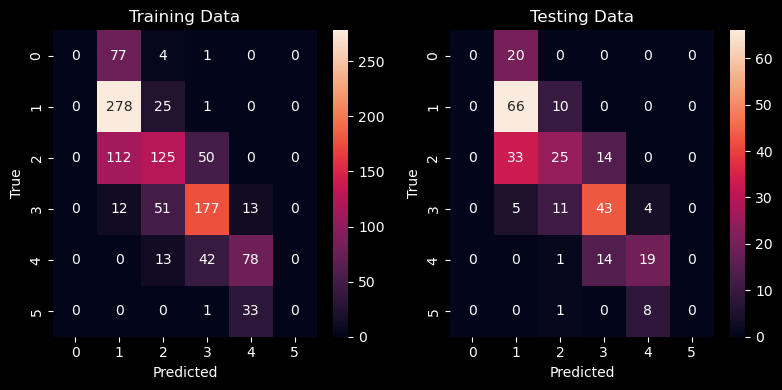

RandomForestClassifier(max_leaf_nodes=30)
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        20
           1       0.57      0.79      0.66        76
           2       0.56      0.54      0.55        72
           3       0.65      0.67      0.66        63
           4       0.67      0.59      0.62        34
           5       1.00      0.33      0.50         9

    accuracy                           0.60       274
   macro avg       0.57      0.49      0.50       274
weighted avg       0.57      0.60      0.57       274



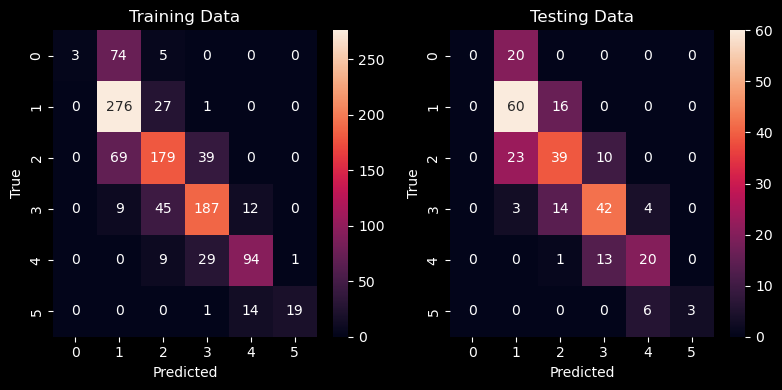

GradientBoostingClassifier(max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.36      0.20      0.26        20
           1       0.57      0.71      0.63        76
           2       0.58      0.54      0.56        72
           3       0.60      0.60      0.60        63
           4       0.58      0.56      0.57        34
           5       0.80      0.44      0.57         9

    accuracy                           0.58       274
   macro avg       0.58      0.51      0.53       274
weighted avg       0.57      0.58      0.57       274



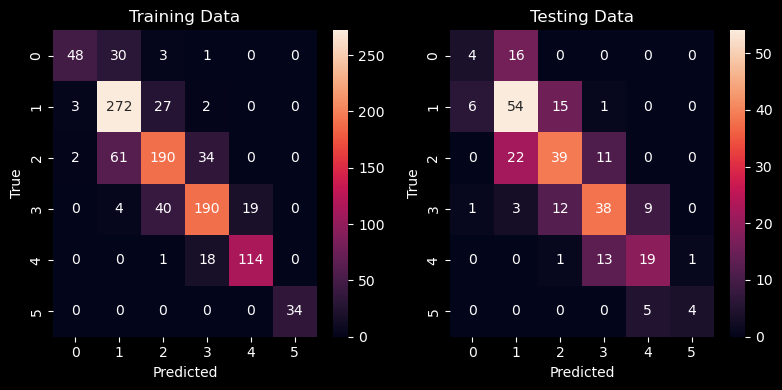

GradientBoostingClassifier(max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       0.33      0.15      0.21        20
           1       0.56      0.66      0.60        76
           2       0.54      0.60      0.57        72
           3       0.63      0.54      0.58        63
           4       0.58      0.62      0.60        34
           5       1.00      0.56      0.71         9

    accuracy                           0.57       274
   macro avg       0.61      0.52      0.55       274
weighted avg       0.57      0.57      0.56       274



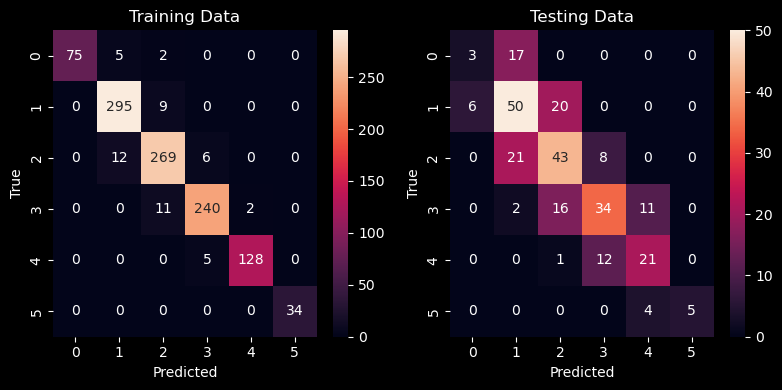

,0,1,2,3,4,5,avg_f1
model,,,,,,,
GradientBoostingClassifier(max_leaf_nodes=10),0.206897,0.602410,0.565789,0.581197,0.600000,0.714286,0.545096
LogisticRegression(),0.388889,0.616352,0.573427,0.593750,0.537313,0.533333,0.540511
KNeighborsClassifier(n_neighbors=10),0.322581,0.606061,0.530612,0.592593,0.526316,0.615385,0.532258
GradientBoostingClassifier(max_leaf_nodes=3),0.258065,0.631579,0.561151,0.603175,0.567164,0.571429,0.532094
RandomForestClassifier(max_leaf_nodes=30),0.000000,0.659341,0.549296,0.656250,0.625000,0.500000,0.498314
KNeighborsClassifier(),0.181818,0.562874,0.520548,0.595420,0.491228,0.571429,0.487219
KNeighborsClassifier(n_neighbors=50),0.000000,0.649746,0.396694,0.573529,0.562500,0.200000,0.397078
RandomForestClassifier(max_leaf_nodes=10),0.000000,0.660000,0.416667,0.641791,0.584615,0.000000,0.383846
RandomForestClassifier(max_leaf_nodes=3),0.000000,0.660550,0.270833,0.549708,0.000000,0.000000,0.246849


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

# Store per-class F1 scores here
f1_rows = []

for m in models:
    
    # Fit model
    m.fit(X_train, y_train)

    # Predictions
    y_train_pred = m.predict(X_train)
    y_test_pred = m.predict(X_test)

    print(m)

    # --- Classification report ---
    report_dict = classification_report(
        y_test,
        y_test_pred,
        output_dict=True
    )

    print(classification_report(y_test, y_test_pred))

    # --- Extract per-class F1 scores ---
    model_name = str(m)

    f1_scores = {
        cls: metrics["f1-score"]
        for cls, metrics in report_dict.items()
        if cls not in ["accuracy", "macro avg", "weighted avg"]
    }

    f1_scores["model"] = model_name

    f1_rows.append(f1_scores)

    # --- Confusion matrices ---
    conf_matrix_train = confusion_matrix(y_train, y_train_pred)
    conf_matrix_test = confusion_matrix(y_test, y_test_pred)

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

    # Training confusion matrix
    sns.heatmap(
        conf_matrix_train,
        annot=True,
        vmin=0,
        fmt='d',
        ax=axes[0]
    )

    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Training Data")

    # Testing confusion matrix
    sns.heatmap(
        conf_matrix_test,
        annot=True,
        vmin=0,
        fmt='d',
        ax=axes[1]
    )

    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Testing Data")

    plt.tight_layout()
    plt.show()

# --- Build final DataFrame ---
f1_df = pd.DataFrame(f1_rows)
f1_df = f1_df.set_index("model")
f1_df = f1_df.reindex(sorted(f1_df.columns, key=float), axis=1)
f1_df['avg_f1'] = f1_df.mean(axis=1)

f1_df.sort_values(by='avg_f1', ascending=False)